# Experiment 8 Analysis: Large Scale VC Repair (300K)
Comparison of Vanilla, Classic, and Weighted VC (with Dynamic Alpha) as a function of Epsilon on 300,000 rows.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Configure seaborn styling
sns.set_theme(style="whitegrid")

# Load flattened data
DATA_PATH = Path("../input/experiment_8_repair_comparison_flat.csv")
df = pd.read_csv(DATA_PATH)

print(f"Loaded {len(df)} records.")
df.head()


Loaded 309 records.


,runtimes,deletion_ratio,marginals_error,tvd_2way,ml_accuracy,violations,loss_function,marginal_generation_quality,marginal_selection_quality,dataset_name,...,ml_acc_repaired,ml_acc_synthetic,ml_acc_logistic_regression_repaired,ml_acc_logistic_regression_synthetic,ml_acc_random_forest_repaired,ml_acc_random_forest_synthetic,ml_acc_mlp_repaired,ml_acc_mlp_synthetic,loss_marginal_repaired,loss_marginal_synthetic
0,{'repair': 230.8269064426422},0.923797,"{'synthetic_avg': 8025000.244968678, 'repaired...","{'synthetic_avg': 0.006832544402788347, 'repai...",{'synthetic': {'logistic_regression': 0.620163...,"{'private': 0, 'synthetic': 8181451, 'repaired...","{'synthetic': {'total': 0.4589798613512613, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps0.2_syn_repaired,...,0.600403,0.607294,0.620070,0.620163,0.562083,0.580915,0.619055,0.620804,0.011286,0.006309
1,{'repair': 229.9134316444397},0.984220,"{'synthetic_avg': 8046666.90731664, 'repaired_...","{'synthetic_avg': 0.011792648147848975, 'repai...",{'synthetic': {'logistic_regression': 0.620180...,"{'private': 0, 'synthetic': 22203671, 'repaire...","{'synthetic': {'total': 0.4589561946845946, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps0.1_syn_repaired,...,0.597339,0.607075,0.618745,0.620180,0.567706,0.580030,0.605565,0.621015,0.013100,0.006262
2,{'repair': 228.44909977912903},0.972737,"{'synthetic_avg': 8050000.2429974405, 'repaire...","{'synthetic_avg': 0.006718833302453073, 'repai...",{'synthetic': {'logistic_regression': 0.620182...,"{'private': 0, 'synthetic': 8194035, 'repaired...","{'synthetic': {'total': 0.4589616113512613, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps0.2_syn_repaired,...,0.596564,0.607216,0.620079,0.620182,0.560163,0.580542,0.609452,0.620924,0.025865,0.006273
3,{'repair': 240.35343313217163},0.986530,"{'synthetic_avg': 8036666.908696361, 'repaired...","{'synthetic_avg': 0.011583109190588775, 'repai...",{'synthetic': {'logistic_regression': 0.620174...,"{'private': 0, 'synthetic': 19968618, 'repaire...","{'synthetic': {'total': 0.45896052801792797, '...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps0.1_syn_repaired,...,0.597053,0.607026,0.620790,0.620174,0.570105,0.579975,0.600263,0.620928,0.020513,0.006271
4,{'repair': 34.32042837142944},0.002807,"{'synthetic_avg': 8025000.244968678, 'repaired...","{'synthetic_avg': 0.006832544402788347, 'repai...",{'synthetic': {'logistic_regression': 0.620163...,"{'private': 0, 'synthetic': 8181451, 'repaired...","{'synthetic': {'total': 0.4589798613512613, 's...",{'avg_relative_error': 1.5151305911681752},"{'precision_at_k': 0.0, 'overlap_count': 0, 'k...",census_loaded_census_aim_eps0.2_syn_repaired,...,0.607218,0.607294,0.620120,0.620163,0.580463,0.580915,0.621070,0.620804,0.006328,0.006309


## 1. Deletion Ratio by Dataset
Analyzes the deletion ratio trends using line plots for each dataset.


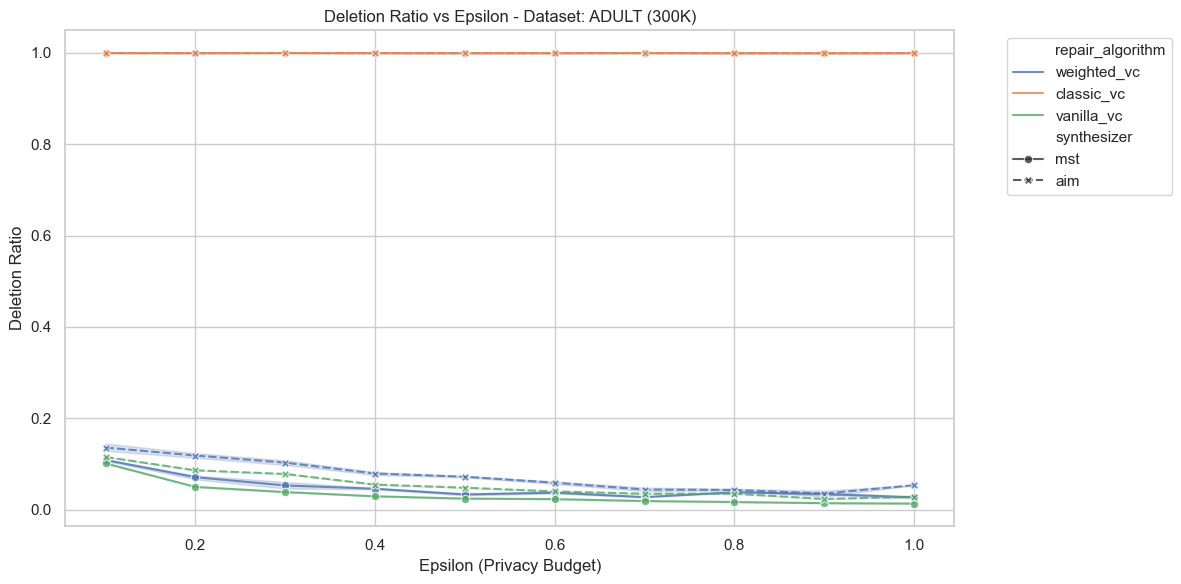

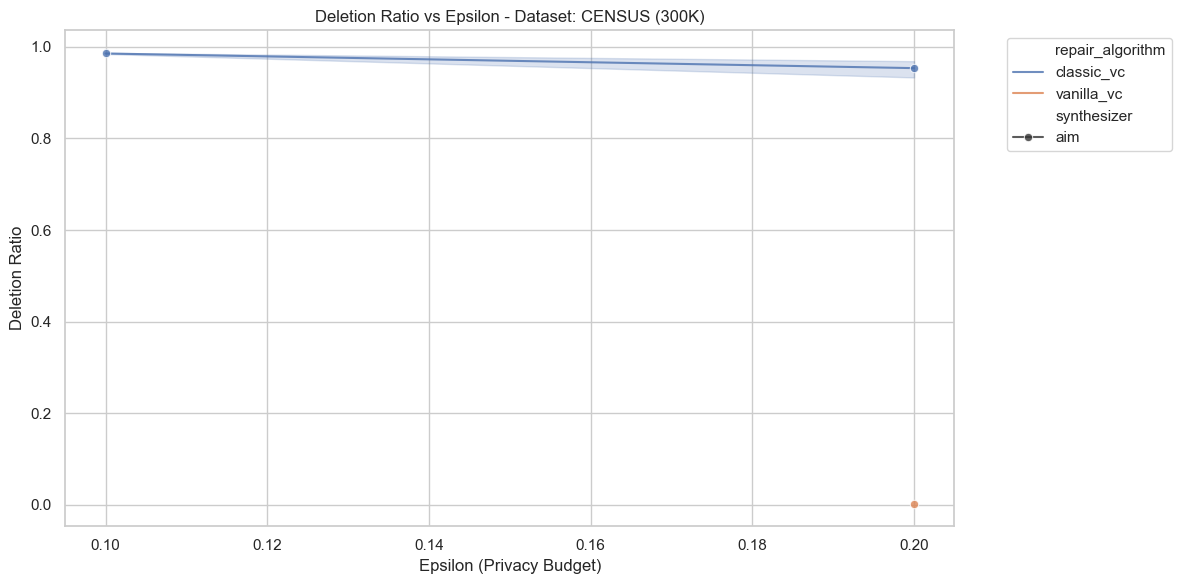

In [2]:
datasets = sorted(df['dataset'].unique())

for dataset in datasets:
    plt.figure(figsize=(12, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="deletion_ratio", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True,
        err_style="band",
        alpha=0.8
    )
    
    plt.title(f"Deletion Ratio vs Epsilon - Dataset: {dataset.upper()} (300K)")
    plt.ylabel("Deletion Ratio")
    plt.xlabel("Epsilon (Privacy Budget)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 2. Marginals Error
Comparative analysis of average 1-way marginals error after repair.


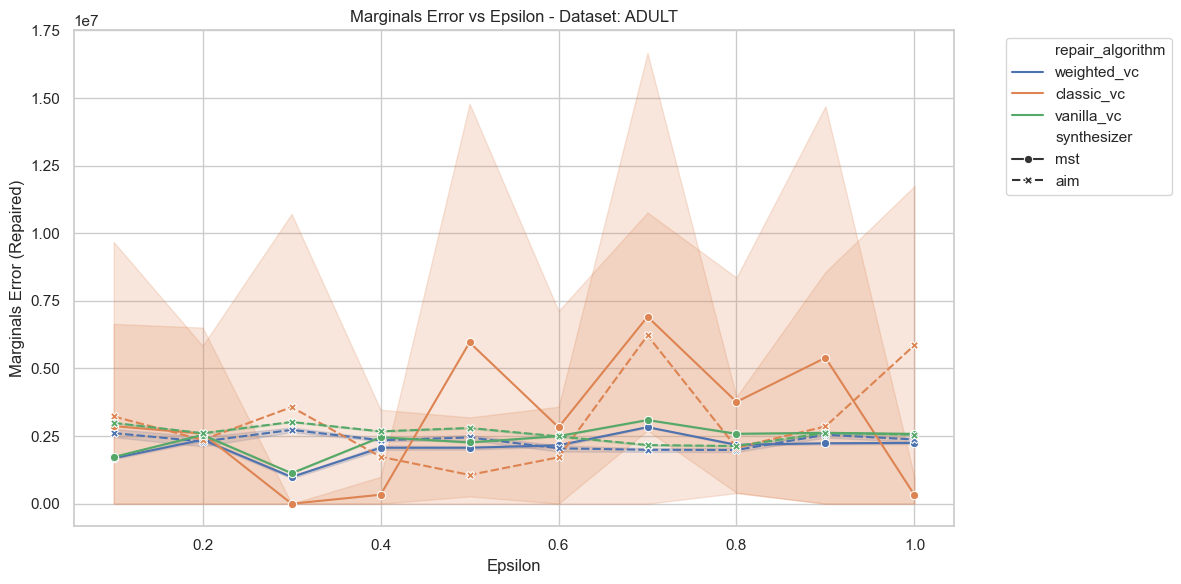

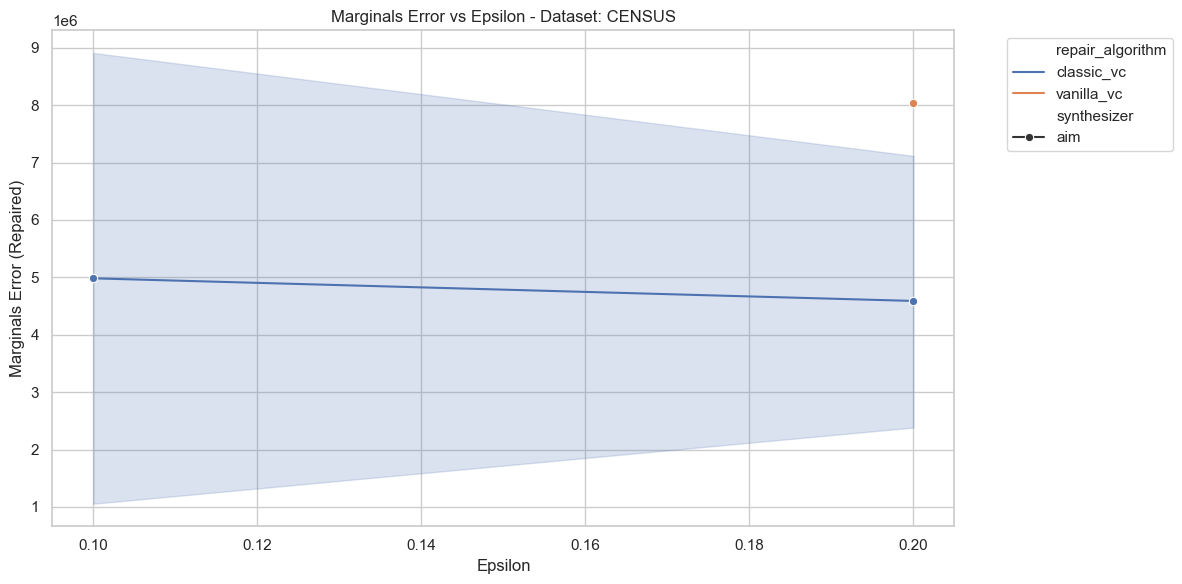

In [3]:
for dataset in datasets:
    plt.figure(figsize=(12, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="marginals_error_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True,
        err_style="band"
    )
    
    plt.title(f"Marginals Error vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Marginals Error (Repaired)")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 3. Total Variation Distance (TVD)
2-way marginals distribution similarity.


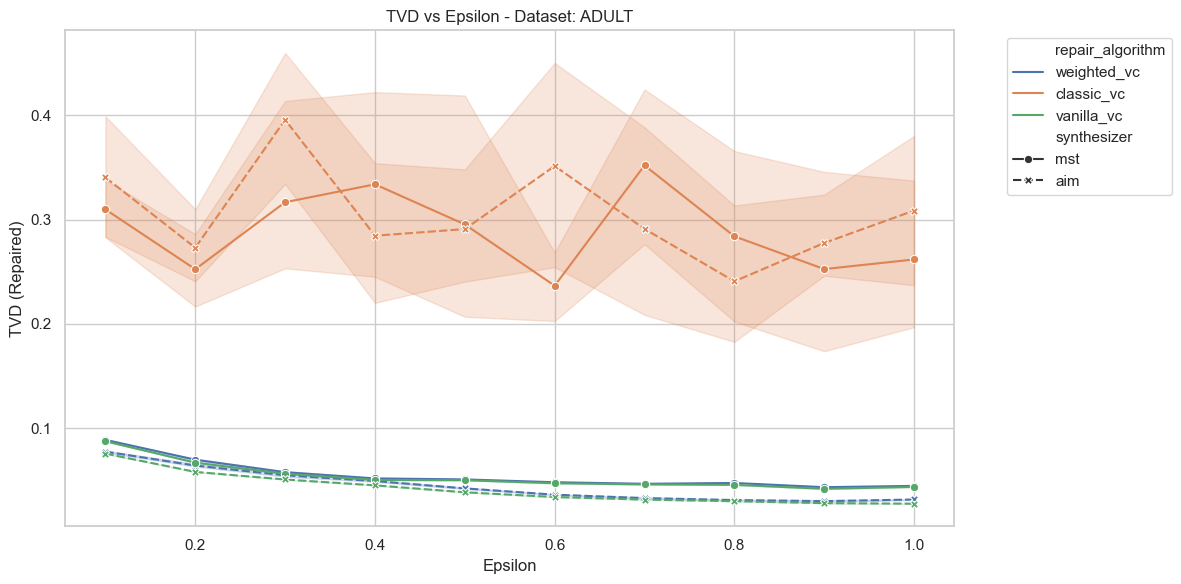

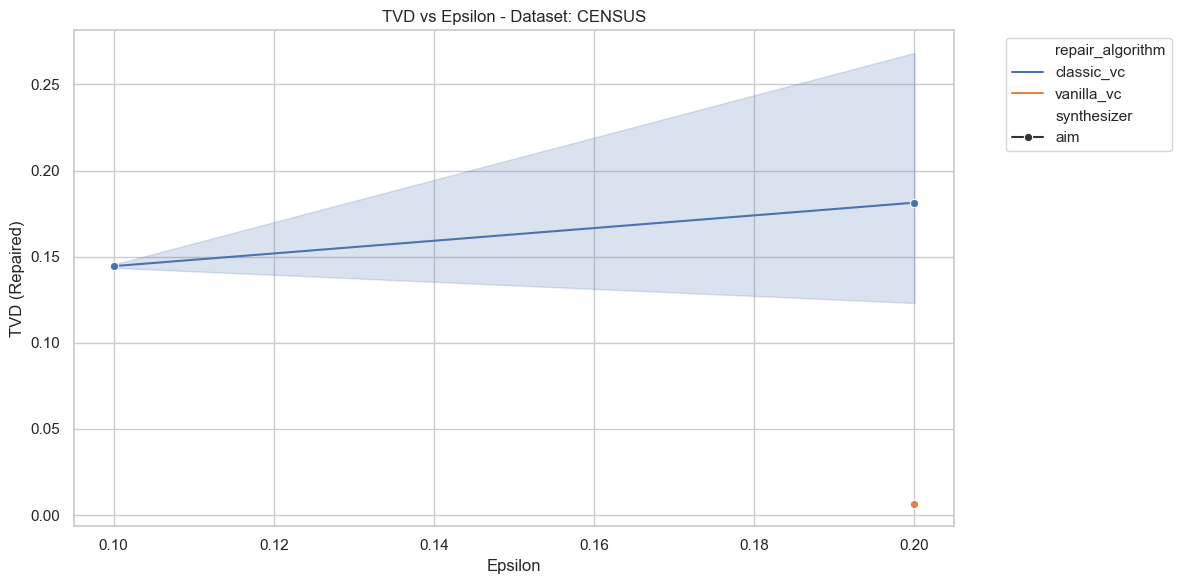

In [4]:
for dataset in datasets:
    plt.figure(figsize=(12, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="tvd_repaired", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"TVD vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("TVD (Repaired)")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 4. Alpha Parameter Evolution (Weighted VC)
Analysis of the dynamic alpha reselection for Weighted VC.


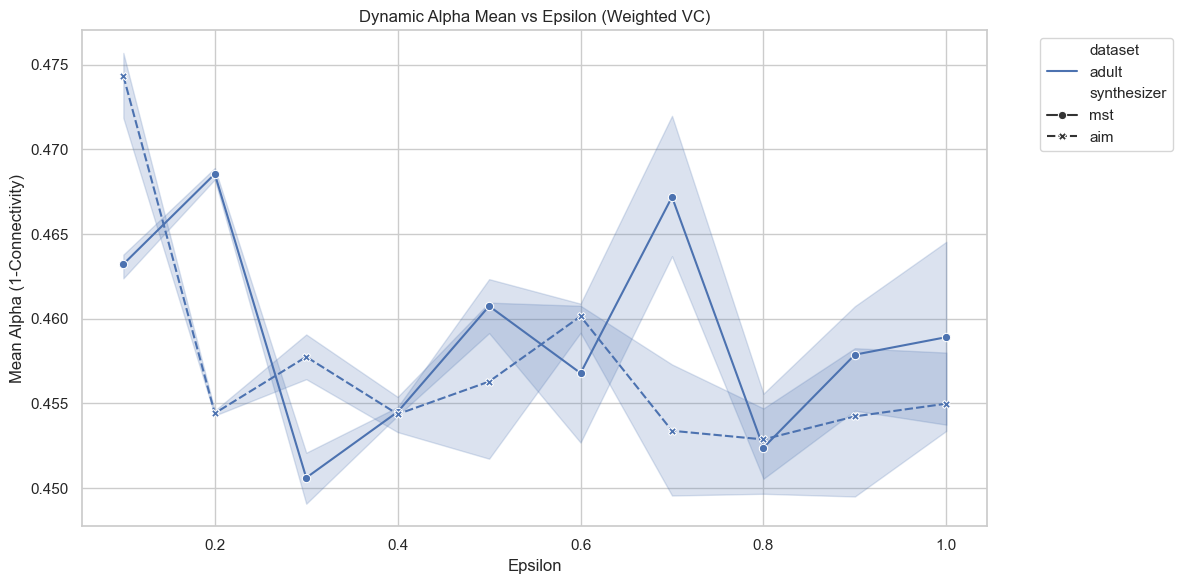

In [5]:
plt.figure(figsize=(12, 6))
weighted_df = df[df['repair_algorithm'] == 'weighted_vc']

if not weighted_df.empty:
    sns.lineplot(
        data=weighted_df,
        x="epsilon",
        y="mean_alpha",
        hue="dataset",
        style="synthesizer",
        markers=True
    )

    plt.title("Dynamic Alpha Mean vs Epsilon (Weighted VC)")
    plt.ylabel("Mean Alpha (1-Connectivity)")
    plt.xlabel("Epsilon")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No weighted_vc results available yet.")


## 5. Runtime Comparison
Comparing the efficiency of the three algorithms at 300K scale.


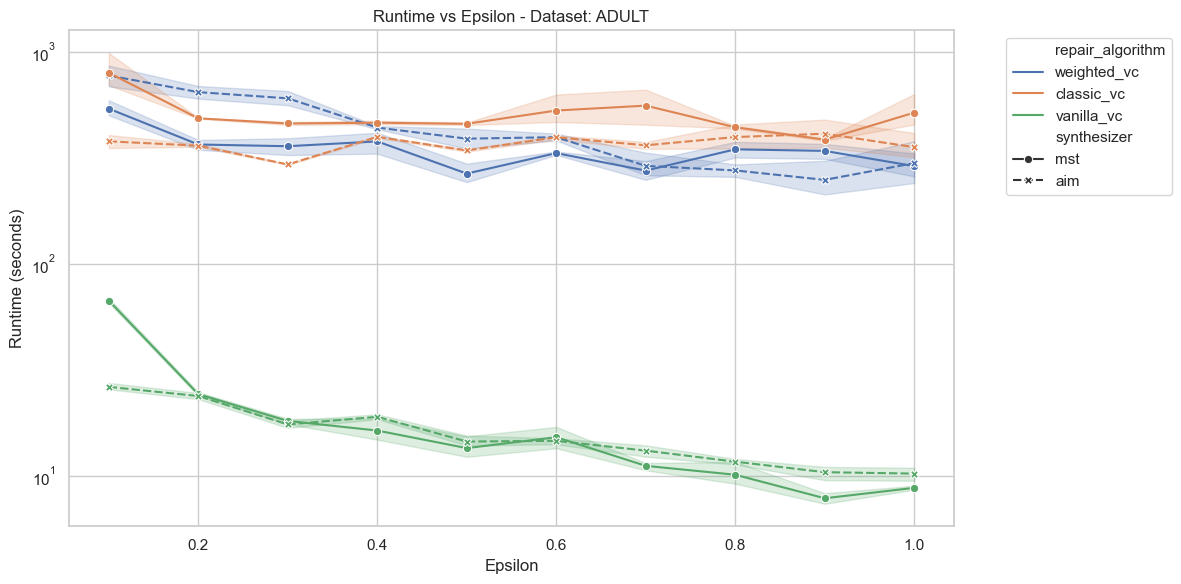

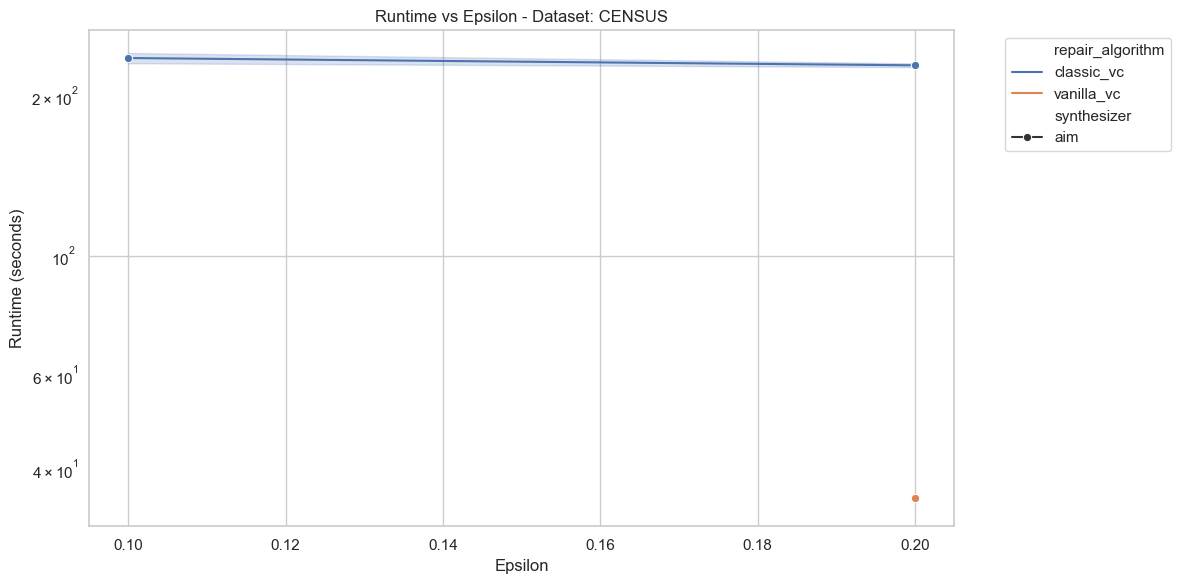

In [6]:
for dataset in datasets:
    plt.figure(figsize=(12, 6))
    subset = df[df['dataset'] == dataset]
    
    sns.lineplot(
        data=subset, 
        x="epsilon", 
        y="repair_runtime", 
        hue="repair_algorithm", 
        style="synthesizer", 
        markers=True, 
        dashes=True
    )
    
    plt.title(f"Runtime vs Epsilon - Dataset: {dataset.upper()}")
    plt.ylabel("Runtime (seconds)")
    plt.xlabel("Epsilon")
    plt.yscale('log')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
